<a href="https://colab.research.google.com/github/Chanaporn042/Ge338-Lab-3/blob/main/Lab_3_Machine_Learning_6606614672.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import ee
import geemap

In [3]:
# 0. Authenticate & Initialize
ee.Authenticate()
ee.Initialize(project='ee-chanaporn040')

Sample size: 2500
==== Random Forest Trees: 100 ====
Confusion Matrix: [[92, 3, 2, 0, 10], [14, 31, 22, 12, 27], [1, 20, 68, 8, 8], [0, 10, 8, 69, 17], [7, 19, 23, 24, 21]]
Overall Accuracy: 0.5445736434108527
Kappa: 0.4301450719250344
==== Random Forest Trees: 200 ====
Confusion Matrix: [[93, 3, 2, 0, 9], [14, 31, 21, 14, 26], [1, 18, 70, 8, 8], [0, 9, 8, 68, 19], [6, 20, 21, 25, 22]]
Overall Accuracy: 0.5503875968992248
Kappa: 0.43745947012772196
==== Random Forest Trees: 500 ====
Confusion Matrix: [[94, 3, 2, 0, 8], [13, 31, 21, 14, 27], [1, 14, 72, 8, 10], [0, 9, 8, 71, 16], [7, 20, 22, 24, 21]]
Overall Accuracy: 0.560077519379845
Kappa: 0.44953662800533867


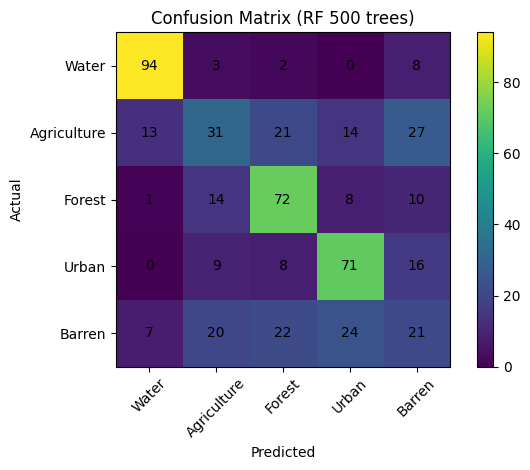


=== Per Class Metrics ===
Class           PA    UA    F1   IoU  Dice    BA
Water         0.88  0.82  0.85  0.73  0.85  0.91
Feature Importance (RF 500 trees):
{'B11': 15649.358681381831, 'B2': 15088.524858408518, 'B3': 14844.298557068754}
Agriculture   0.29  0.40  0.34  0.20  0.34  0.59
Feature Importance (RF 500 trees):
{'B11': 15649.358681381831, 'B2': 15088.524858408518, 'B3': 14844.298557068754}
Forest        0.69  0.58  0.63  0.46  0.63  0.78
Feature Importance (RF 500 trees):
{'B11': 15649.358681381831, 'B2': 15088.524858408518, 'B3': 14844.298557068754}
Urban         0.68  0.61  0.64  0.47  0.64  0.79
Feature Importance (RF 500 trees):
{'B11': 15649.358681381831, 'B2': 15088.524858408518, 'B3': 14844.298557068754}
Barren        0.22  0.26  0.24  0.14  0.24  0.54
Feature Importance (RF 500 trees):
{'B11': 15649.358681381831, 'B2': 15088.524858408518, 'B3': 14844.298557068754}


Map(center=[13.0, 101.2], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

In [5]:
# ======================================
# 1. Map
# ======================================
Map = geemap.Map(center=[13.0, 101.2], zoom=9)

# ======================================
# 2. ROI: Rayong + Chonburi + Chachoengsao
# ======================================
provinces = ee.FeatureCollection("FAO/GAUL/2015/level1")
roi = (provinces.filter(ee.Filter.eq('ADM1_NAME','Rayong')))
       #.merge(provinces.filter(ee.Filter.eq('ADM1_NAME','Chonburi')))
       #.merge(provinces.filter(ee.Filter.eq('ADM1_NAME','Chachoengsao'))))

Map.addLayer(roi, {'color':'red'}, 'ROI')

# ======================================
# 3. Sentinel-2 Image
# ======================================
def cloudMask(img):
    scl = img.select('SCL')
    mask = (scl.neq(3)
            .And(scl.neq(8))
            .And(scl.neq(9))
            .And(scl.neq(10))
            .And(scl.neq(11)))
    return img.updateMask(mask)

s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
      .filterBounds(roi)
      .filterDate('2024-01-01','2024-12-31')
      .map(cloudMask)
      .select(['B2','B3','B4','B8','B11',])
      .median()
      .clip(roi))

#4. Spectral Indices (ตัด NDVI, NDWI, NDBI ออก)
#ไม่ต้องสร้าง NDVI, NDWI, NDBI
image = s2.select(['B2','B3','B11'])  # ใช้เฉพาะ Sentinel-2 bands ที่เหลือ
selectedBands = ['B2','B3','B11']      # RF / K-Means จะใช้เฉพาะ bands นี้

# ======================================
# 4. Spectral Indices
# ======================================
#ndvi = s2.normalizedDifference(['B8','B4']).rename('NDVI')
#ndwi = s2.normalizedDifference(['B3','B8']).rename('NDWI')
#ndbi = s2.normalizedDifference(['B11','B8']).rename('NDBI')

#image = s2.addBands([ndvi, ndwi, ndbi])
#selectedBands = ['B2','B3','B4','B8','B11','NDWI','NDVI','NDBI']
# ======================================
# K-Means Clustering (Baseline)
# ======================================
#numClusters = 5  # จำนวน clusters
#trainingCluster = image.select(selectedBands).sample(
#    region=roi,
#    scale=10,
#    numPixels=1000
#)

#clusterer = ee.Clusterer.wekaKMeans(numClusters).train(trainingCluster)
#kmeans = image.select(selectedBands).cluster(clusterer)

# แสดงบน Map
#Map.addLayer(kmeans.randomVisualizer(), {}, 'KMeans')
# ======================================
# 5. ESA WorldCover as Training
# ======================================
# Load ESA WorldCover 2020
lc = ee.Image("ESA/WorldCover/v100/2020").select('Map').clip(roi)

# Reclass: 0=Water,1=Agri,2=Forest,3=Urban,4=Barren
lc_reclass = lc.remap(
    [10,20,30,40,50,60,80,90],
    [2,2,2,1,3,4,0,4]
)

Map.addLayer(lc_reclass, {}, 'ESA Reclass')

# ======================================
# 6. Stratified Sample
# ======================================
samples = image.addBands(lc_reclass.rename('class')).stratifiedSample(
    numPoints=500,  # ปรับตาม memory / ขนาดพื้นที่
    classBand='class',
    region=roi,
    scale=10,
    geometries=True
)

# Split train / validation 80/20
withRandom = samples.randomColumn('random')
train = withRandom.filter(ee.Filter.lt('random', 0.8))
test = withRandom.filter(ee.Filter.gte('random', 0.8)) # Renamed val to test for consistency

print("Sample size:", samples.size().getInfo())

# ======================================
# Random Forest Loop (100, 200, 500 trees)
# ======================================
treesList = [100, 200, 500]
palette = ['blue','yellow','green','red','gray']  # Water, Agri, Green, Urban, Barren

for numTrees in treesList:
    print(f'==== Random Forest Trees: {numTrees} ====')

    # 1️⃣ Train classifier
    rf = ee.Classifier.smileRandomForest(numTrees).train(
        features=train,
        classProperty='class',
        inputProperties=selectedBands
    )

    # 2️⃣ Classification
    classified = image.select(selectedBands).classify(rf).toInt()
    # Reproject for visualization to avoid timeout
    classified_display = classified.reproject(crs='EPSG:4326', scale=100)
    Map.addLayer(classified_display, {'min':0,'max':4,'palette':palette}, f'RF_{numTrees}')

    # 3️⃣ Accuracy
    valClass = test.classify(rf) # Used test instead of val
    cm = valClass.errorMatrix('class','classification')
    print('Confusion Matrix:', cm.getInfo())
    print('Overall Accuracy:', cm.accuracy().getInfo())
    print('Kappa:', cm.kappa().getInfo())

    # ======================================
# 📊 Plot Confusion Matrix (Matplotlib)
# ======================================
cm_array = np.array(cm.getInfo())

plt.figure()
plt.imshow(cm_array)
plt.title(f'Confusion Matrix (RF {numTrees} trees)')
plt.colorbar()

# Labels
classes = ['Water','Agriculture','Forest','Urban','Barren']
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

# ใส่ค่าลงในช่อง
for i in range(cm_array.shape[0]):
    for j in range(cm_array.shape[1]):
        plt.text(j, i, cm_array[i, j],
                 ha='center', va='center')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()
        # ======================================
    # ======================================
# 3.1 Advanced Metrics per Class
# ======================================
matrix = cm.getInfo()  # <-- คืน list of lists โดยตรง
n = len(matrix)

class_names = ['Water','Agriculture','Forest','Urban','Barren']

print("\n=== Per Class Metrics ===")
print(f"{'Class':<12}{'PA':>6}{'UA':>6}{'F1':>6}{'IoU':>6}{'Dice':>6}{'BA':>6}")

total = sum([sum(row) for row in matrix])

for i in range(n):
    TP = matrix[i][i]
    FN = sum(matrix[i]) - TP
    FP = sum([matrix[r][i] for r in range(n)]) - TP
    TN = total - (TP + FN + FP)

    PA = TP / (TP + FN) if (TP + FN) > 0 else 0
    UA = TP / (TP + FP) if (TP + FP) > 0 else 0
    F1 = 2 * TP / (2*TP + FP + FN) if (2*TP + FP + FN) > 0 else 0
    IoU = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
    Dice = 2 * TP / (2*TP + FP + FN) if (2*TP + FP + FN) > 0 else 0
    TNR = TN / (TN + FP) if (TN + FP) > 0 else 0
    BA = (PA + TNR) / 2

    print(f"{class_names[i]:<12}{PA:6.2f}{UA:6.2f}{F1:6.2f}{IoU:6.2f}{Dice:6.2f}{BA:6.2f}")
    # 4️⃣ Feature Importance
    importance = rf.explain().get('importance')
    print(f'Feature Importance (RF {numTrees} trees):')
    print(ee.Dictionary(importance).getInfo())

    # 5️⃣ Low Confidence Map (<0.5)
    prob = image.select(selectedBands).classify(rf.setOutputMode('MULTIPROBABILITY'))
    maxProb = prob.arrayReduce(ee.Reducer.max(), axes=[0])
    maxProbScalar = maxProb.arrayProject([0]).arrayFlatten([['maxProb']])
    lowConf = maxProbScalar.lt(0.5)

    # Reproject for visualization to avoid timeout
    maxProbScalar_display = maxProbScalar.reproject(crs='EPSG:4326', scale=100)
    # Confidence gradient
    Map.addLayer(maxProbScalar_display, {'min':0,'max':1,'palette':['red','yellow','green']}, f'Confidence_{numTrees}')

    # Reproject for visualization to avoid timeout
    lowConf_display = lowConf.reproject(crs='EPSG:4326', scale=100)
    # Highlight low confidence pixels
    Map.addLayer(lowConf_display.selfMask(), {'palette':['black']}, f'LowConf_{numTrees}')

# 6️⃣ Show Map
Map

In [ ]:
# เริ่ม export
task = ee.batch.Export.image.toDrive(
    image=classified,           # ภาพที่ต้องการส่งออก
    description='Kmeans2',
    folder='Lab3',        # folder ต้องมีอยู่จริงใน Google Drive
    fileNamePrefix='Kmeans2',
    region=roi.geometry(),
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()  # เริ่มงาน export
print('Export started!')

# ตรวจสถานะทันที (ไม่ต้องรอ loop)
print(task.status())

Export started!
{'state': 'READY', 'description': 'Kmeans2', 'priority': 100, 'creation_timestamp_ms': 1774961842567, 'update_timestamp_ms': 1774961842567, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': '3C2AQQCKY4HPU5MOSNEH7UVW', 'name': 'projects/ee-chanaporn040/operations/3C2AQQCKY4HPU5MOSNEH7UVW'}
